In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
ds = load_dataset("slegroux/tiny-imagenet-200-clean")

In [ ]:
from datasets import load_dataset
import torchvision.transforms as transforms
import torch
import numpy as np
from PIL import Image
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from torchvision.models import resnet18

# Load Tiny ImageNet
ds = load_dataset("slegroux/tiny-imagenet-200-clean", split="train")

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create a random tensor for images
images = torch.randn(1000, 3, 224, 224)

print(images.shape)

# Create random labels
labels = np.random.choice(['cat', 'dog'], size=images.shape[0])

labels = np.array(labels)
if labels.ndim > 1:
    labels = labels.ravel()

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(labels)
labels = torch.LongTensor(labels)

print(images.shape, labels.shape)

# Split data
X_train_tensor, X_val_tensor, y_train_tensor, y_val_tensor = train_test_split(
    images, labels, test_size=0.2, stratify=labels
)

print(X_train_tensor.shape, X_val_tensor.shape)
print(y_train_tensor.shape, y_val_tensor.shape)

torch.Size([1000, 3, 224, 224])
torch.Size([1000, 3, 224, 224]) torch.Size([1000])
torch.Size([800, 3, 224, 224]) torch.Size([200, 3, 224, 224])
torch.Size([800]) torch.Size([200])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import resnet18
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create random tensor for images
images = torch.randn(1000, 3, 224, 224)

# Create random labels
labels = np.random.choice(['cat', 'dog'], size=images.shape[0])

# Preprocess labels
labels = np.array(labels)
if labels.ndim > 1:
    labels = labels.ravel()

le = LabelEncoder()
labels = le.fit_transform(labels)
labels = torch.LongTensor(labels)

# Split train and validation
X_train_tensor, X_val_tensor, y_train_tensor, y_val_tensor = train_test_split(
    images, labels, test_size=0.2, stratify=labels
)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Load pretrained ResNet18
resnet = resnet18(pretrained=True)

# Modify the final FC layer for binary classification
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = resnet.to(device)

# Define optimizer, loss function, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Training loop
epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation
    resnet.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = resnet(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    val_loss = running_loss / total
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

print("Training completed!")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10] - Train Loss: 0.8815, Train Acc: 0.4938, Val Loss: 0.6999, Val Acc: 0.5250
Epoch [2/10] - Train Loss: 0.5329, Train Acc: 0.7175, Val Loss: 1.5005, Val Acc: 0.4800
Epoch [3/10] - Train Loss: 0.1580, Train Acc: 0.9350, Val Loss: 3.3162, Val Acc: 0.5100
Epoch [4/10] - Train Loss: 0.0789, Train Acc: 0.9688, Val Loss: 1.7966, Val Acc: 0.5050
Epoch [5/10] - Train Loss: 0.0470, Train Acc: 0.9825, Val Loss: 1.9234, Val Acc: 0.4650
Epoch [6/10] - Train Loss: 0.0230, Train Acc: 0.9925, Val Loss: 2.1281, Val Acc: 0.4950
Epoch [7/10] - Train Loss: 0.0072, Train Acc: 0.9988, Val Loss: 2.0914, Val Acc: 0.5050
Epoch [8/10] - Train Loss: 0.0023, Train Acc: 1.0000, Val Loss: 1.8595, Val Acc: 0.4600
Epoch [9/10] - Train Loss: 0.0013, Train Acc: 1.0000, Val Loss: 1.9353, Val Acc: 0.4600
Epoch [10/10] - Train Loss: 0.0009, Train Acc: 1.0000, Val Loss: 1.9504, Val Acc: 0.4650
Training completed!


In [ ]:
# Save trained model
torch.save(resnet.state_dict(), 'resnet18_trained.pth')
print("Trained model saved!")

Trained model saved!


In [ ]:
# Reload the model with 2 classes architecture
resnet = resnet18(pretrained=False)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

# Load the saved weights
resnet.load_state_dict(torch.load('resnet18_trained.pth'))
resnet.eval()  # Set to evaluation mode

# Remove the final FC layer for feature extraction
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


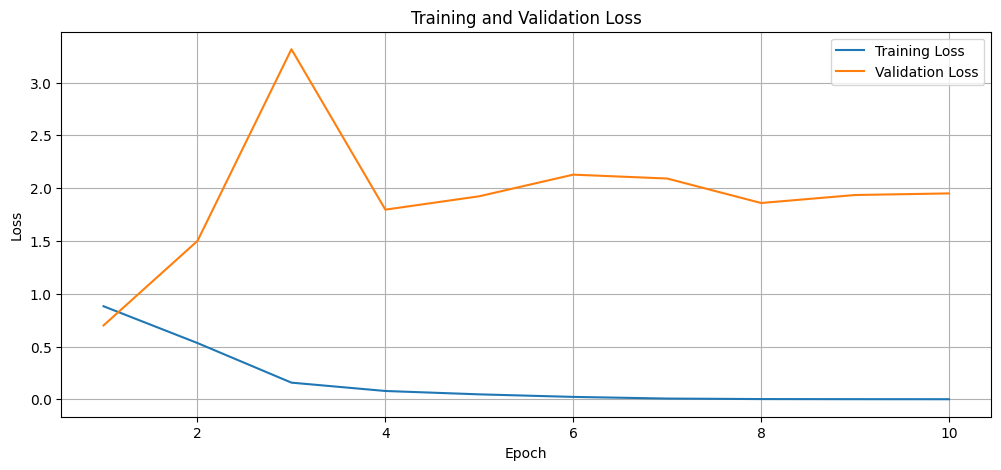

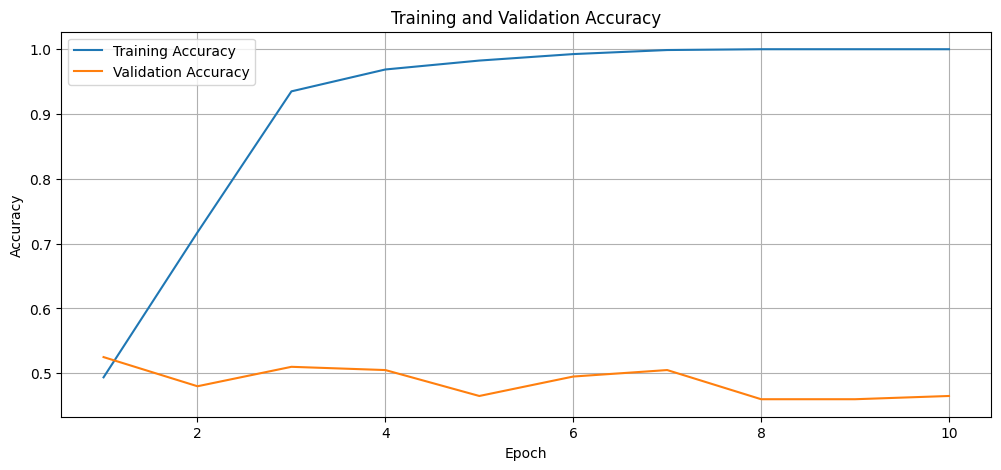

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

# Plot Loss
plt.figure(figsize=(12, 5))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from itertools import combinations
import random

# Feature extraction using ResNet18
resnet = resnet18(pretrained=True)
resnet.eval()
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])

# Freeze all layers in ResNet18
for param in resnet.parameters():
    param.requires_grad = False


def extract_features(images):
    with torch.no_grad():
        images = torch.stack([transform(img) for img in images])
        features = resnet(images).squeeze(-1).squeeze(-1)
        return normalize(features.numpy())

# Using subset for speed
N = 1000
images = [ds[i]['image'] for i in range(N)]
labels = np.array([ds[i]['label'] for i in range(N)])
features = extract_features(images)

def generate_pairs(features, labels, num_pairs=5000):
    """Generate positive (same class) and negative (different class) pairs"""
    pairs = []
    pair_labels = []
    class_indices = {}

    # Group indices by class
    for i, label in enumerate(labels):
        if label not in class_indices:
            class_indices[label] = []
        class_indices[label].append(i)

    # Positive pairs (same class)
    for cls, indices in class_indices.items():
        if len(indices) >= 2:
            for i, j in combinations(indices, 2):
                if len(pairs) >= num_pairs//2:
                    break
                pairs.append((features[i], features[j]))
                pair_labels.append(1)

    # Negative pairs (different classes)
    while len(pairs) < num_pairs:
        cls1, cls2 = random.sample(list(class_indices.keys()), 2)
        i = random.choice(class_indices[cls1])
        j = random.choice(class_indices[cls2])
        pairs.append((features[i], features[j]))
        pair_labels.append(0)

    return np.array(pairs), np.array(pair_labels)

# Similarity Computation
from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity(pair):
    return cosine_similarity(pair[0].reshape(1, -1), pair[1].reshape(1, -1))[0][0]

# Generate and evaluate pairs
pairs, pair_labels = generate_pairs(features, labels, num_pairs=2000)
train_pairs, val_pairs, train_labels, val_labels = train_test_split(
    pairs, pair_labels, test_size=0.2, random_state=42
)

In [ ]:
# Training/Evaluation
def evaluate_pairs(pairs, labels, threshold):
    correct = 0
    for (x1, x2), label in zip(pairs, labels):
        sim = compute_similarity((x1, x2))
        pred = 1 if sim >= threshold else 0
        if pred == label:
            correct += 1
    return correct / len(pairs)


# Find optimal threshold
thresholds = np.linspace(0, 1, 50)
best_threshold = 0.5
best_acc = 0
for thresh in thresholds:
    acc = evaluate_pairs(train_pairs, train_labels, thresh)
    if acc > best_acc:
        best_acc = acc
        best_threshold = thresh

# Final evaluation
val_acc = evaluate_pairs(val_pairs, val_labels, best_threshold)
print(f"Validation Accuracy: {val_acc:.2%}")
# Split into training and validation
X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, stratify=labels)

Validation Accuracy: 86.25%


In [ ]:
def train_komp_similarity(X_train_pairs, y_train_pairs, max_iter=30, tol=1e-4):
    """
    Optimized KOMP-based similarity threshold learning.
    Args:
        X_train_pairs: List of feature pairs (shape [N, 2, feature_dim])
        y_train_pairs: Labels (1=similar, 0=dissimilar)
    Returns:
        best_threshold: Optimal similarity threshold
        K_train: Kernel matrix (for later use if needed)
    """
    # Compute Kernel Matrix efficiently
    N = len(X_train_pairs)
    K_train = np.zeros((N, N))

    # Precompute all individual similarities
    sim_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(i, N):
            sim_matrix[i,j] = compute_similarity([X_train_pairs[i][0], X_train_pairs[j][0]])
            sim_matrix[j,i] = sim_matrix[i,j]

    # Spectrum Clipping
    U, sigma, VT = np.linalg.svd(sim_matrix)
    K_train = U @ np.diag(np.clip(sigma, 0, None)) @ VT

    # Threshold Search
    thresholds = np.linspace(0, 1, 100)
    best_threshold = 0.5
    best_accuracy = 0

    # Precompute all pair similarities
    pair_similarities = np.array([compute_similarity(pair) for pair in X_train_pairs])

    for threshold in thresholds:
        preds = (pair_similarities >= threshold).astype(int)
        accuracy = np.mean(preds == y_train_pairs)

        if best_accuracy >= 0.99:
              print(f"Early stopping at threshold {threshold:.3f} (accuracy={accuracy:.2%})")
              break
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    return best_threshold, K_train

# Train and evaluate
threshold, K_train = train_komp_similarity(train_pairs, train_labels)
print(f"Optimal threshold: {threshold:.4f}")

Optimal threshold: 0.6768


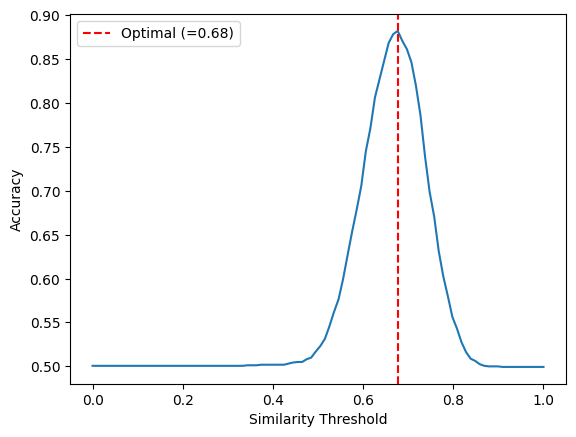

In [ ]:
# Similarity threshold vs accuracy plot
pair_similarities = np.array([compute_similarity(pair) for pair in train_pairs])

thresholds = np.linspace(0, 1, 100)
accuracies = [np.mean((pair_similarities >= t).astype(int) == train_labels)
             for t in thresholds]

plt.plot(thresholds, accuracies)
plt.axvline(threshold, color='r', linestyle='--', label=f'Optimal (={threshold:.2f})')
plt.xlabel("Similarity Threshold")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# Training/Evaluation
def evaluate_pairs(pairs, labels, threshold):
    correct = 0
    for (x1, x2), label in zip(pairs, labels):
        sim = compute_similarity((x1, x2))
        pred = 1 if sim >= threshold else 0
        if pred == label:
            correct += 1
    return correct / len(pairs)

val_acc = evaluate_pairs(val_pairs, val_labels, threshold)
print(f"Validation Accuracy: {val_acc:.2%}")

Validation Accuracy: 86.50%


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def spectrum_clip(S):
    U, sigma, VT = np.linalg.svd(S)
    sigma_clipped = np.clip(sigma, 0, None)
    return U @ np.diag(sigma_clipped) @ VT

# Training kernel
S_train = cosine_similarity(X_train)
K_train = spectrum_clip(S_train)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Obtaining predictions on validation pairs
val_preds = []
for pair in val_pairs:
    sim = compute_similarity(pair)
    val_preds.append(1 if sim >= threshold else 0)

print("Pairwise Similarity Performance:")
print(classification_report(val_labels, val_preds))
print("\nConfusion Matrix:")
print(confusion_matrix(val_labels, val_preds))

Pairwise Similarity Performance:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       201
           1       0.87      0.86      0.86       199

    accuracy                           0.86       400
   macro avg       0.87      0.86      0.86       400
weighted avg       0.87      0.86      0.86       400


Confusion Matrix:
[[175  26]
 [ 28 171]]


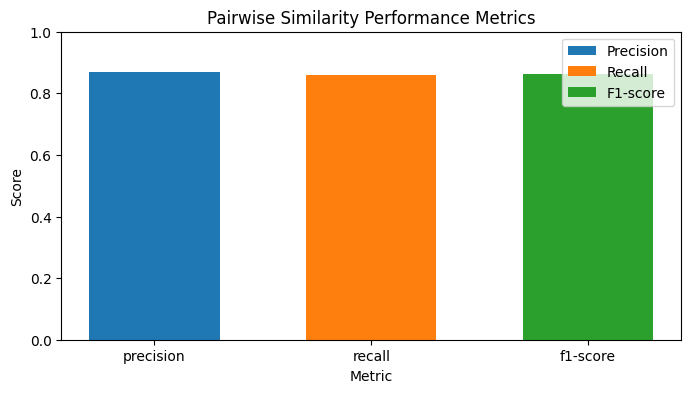

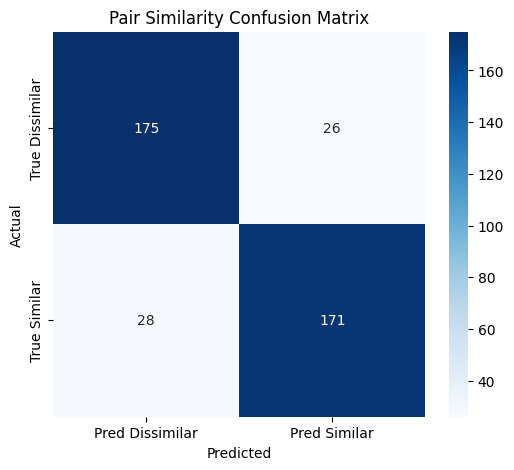

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on validation pairs
val_preds = np.array([1 if compute_similarity(pair) >= threshold else 0
                     for pair in val_pairs])

# Generate binary classification reports
report = classification_report(val_labels, val_preds, output_dict=True, target_names=['Dissimilar', 'Similar'])
conf_matrix = confusion_matrix(val_labels, val_preds)

# Plot binary classification metrics
plt.figure(figsize=(8, 4))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(metrics))
width = 0.25

for i, metric in enumerate(metrics):
    plt.bar(x[i], report['Similar'][metric], width=0.6, label=metric.capitalize())

plt.xticks(x, metrics)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Pairwise Similarity Performance Metrics")
plt.legend()
plt.show()

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Dissimilar', 'Pred Similar'],
            yticklabels=['True Dissimilar', 'True Similar'])
plt.title("Pair Similarity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **HYPERPARAMTER TUNING**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, rbf_kernel
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score
from numpy.linalg import svd, solve
import numpy as np
import pandas as pd

# Defining the parameter grid
param_grid = {
    'kernel': ['cosine', 'rbf'],
    'gamma': [0.01, 0.05, 0.1],
    'max_iter': [5, 10, 20, 30],
    'tol': [1e-3, 1e-4, 1e-5]
}

results = []

for params in ParameterGrid(param_grid):
    print(f"Testing {params}")
    if params['kernel'] == 'cosine':
        S_train = cosine_similarity(X_train)
        s_func = lambda x: cosine_similarity(X_train, x.reshape(1, -1)).flatten()
    else:
        S_train = rbf_kernel(X_train, gamma=params['gamma'])
        s_func = lambda x: rbf_kernel(X_train, x.reshape(1, -1), gamma=params['gamma']).flatten()

    # Spectrum clip
    U, sigma, VT = svd(S_train)
    P = U @ np.diag(np.clip(sigma, 0, None)) @ U.T
    K_train = P @ S_train

    preds = []
    for i in range(len(X_val)):
        s_raw = s_func(X_val[i])
        s = P @ s_raw

        n = K_train.shape[0]
        w = np.zeros(n)
        active_set = []
        residual_prev = 1.0

        for _ in range(params['max_iter']):
            residual_vector = s - K_train @ w
            idx = np.argmax(np.abs(residual_vector))
            if idx in active_set: break
            active_set.append(idx)
            K_sub = K_train[np.ix_(active_set, active_set)]
            s_sub = s[active_set]
            try:
                w_sub = solve(K_sub, s_sub)
            except np.linalg.LinAlgError:
                break
            w = np.zeros(n)
            w[active_set] = w_sub
            residual_new = 1.0 - 2 * np.dot(w, s) + np.dot(w, K_train @ w)
            if residual_prev - residual_new < params['tol'] * residual_prev:
                break
            residual_prev = residual_new

        # Classification
        residuals = []
        for cls in np.unique(y_train):
            idx = np.where(y_train == cls)[0]
            w_c, s_c = w[idx], s[idx]
            K_c = K_train[np.ix_(idx, idx)]
            r = 1.0 - 2 * np.dot(w_c, s_c) + np.dot(w_c, K_c @ w_c)
            residuals.append(r)
        pred = np.unique(y_train)[np.argmin(residuals)]
        preds.append(pred)

    acc = accuracy_score(y_val, preds)
    results.append({'params': params, 'accuracy': acc})

# Converting to DataFrame
results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
print(results_df.head(10))

Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 5, 'tol': 0.001}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 5, 'tol': 0.0001}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 5, 'tol': 1e-05}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 10, 'tol': 0.001}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 10, 'tol': 0.0001}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 10, 'tol': 1e-05}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 20, 'tol': 0.001}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 20, 'tol': 0.0001}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 20, 'tol': 1e-05}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 30, 'tol': 0.001}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 30, 'tol': 0.0001}
Testing {'gamma': 0.01, 'kernel': 'cosine', 'max_iter': 30, 'tol': 1e-05}
Testing {'gamma': 0.01, 'kernel': 'rbf', 'max_iter': 5, 'tol': 0.001}
Testing {'gamma': 0.01, 'kernel': 'rbf', 

In [ ]:
from sklearn.metrics import accuracy_score

# Use best hyperparameters from results_df
best_params = results_df.sort_values(by='accuracy', ascending=False).iloc[0]['params']

# Rebuild kernel matrix with best kernel choice
if best_params['kernel'] == 'cosine':
    S_train = cosine_similarity(X_train)
    s_func = lambda x: cosine_similarity(X_train, x.reshape(1, -1)).flatten()
else:
    S_train = rbf_kernel(X_train, gamma=best_params['gamma'])
    s_func = lambda x: rbf_kernel(X_train, x.reshape(1, -1), gamma=best_params['gamma']).flatten()

# Spectrum clip
U, sigma, VT = svd(S_train)
P = U @ np.diag(np.clip(sigma, 0, None)) @ U.T
K_train = P @ S_train

# Predict using best hyperparameters
preds = []
for i in range(len(X_val)):
    s_raw = s_func(X_val[i])
    s = P @ s_raw

    n = K_train.shape[0]
    w = np.zeros(n)
    active_set = []
    residual_prev = 1.0

    for _ in range(best_params['max_iter']):
        residual_vector = s - K_train @ w
        idx = np.argmax(np.abs(residual_vector))
        if idx in active_set: break
        active_set.append(idx)
        K_sub = K_train[np.ix_(active_set, active_set)]
        s_sub = s[active_set]
        try:
            w_sub = solve(K_sub, s_sub)
        except np.linalg.LinAlgError:
            break
        w = np.zeros(n)
        w[active_set] = w_sub
        residual_new = 1.0 - 2 * np.dot(w, s) + np.dot(w, K_train @ w)
        if residual_prev - residual_new < best_params['tol'] * residual_prev:
            break
        residual_prev = residual_new

    residuals = []
    for cls in np.unique(y_train):
        idx = np.where(y_train == cls)[0]
        w_c = w[idx]
        s_c = s[idx]
        K_c = K_train[np.ix_(idx, idx)]
        r = 1.0 - 2 * np.dot(w_c, s_c) + np.dot(w_c, K_c @ w_c)
        residuals.append(r)

    pred = np.unique(y_train)[np.argmin(residuals)]
    preds.append(pred)

# Show final accuracy
final_val_accuracy = accuracy_score(y_val, preds)
print(f" Final Validation Accuracy using best parameters: {final_val_accuracy:.2%}")

 Final Validation Accuracy using best parameters: 98.50%


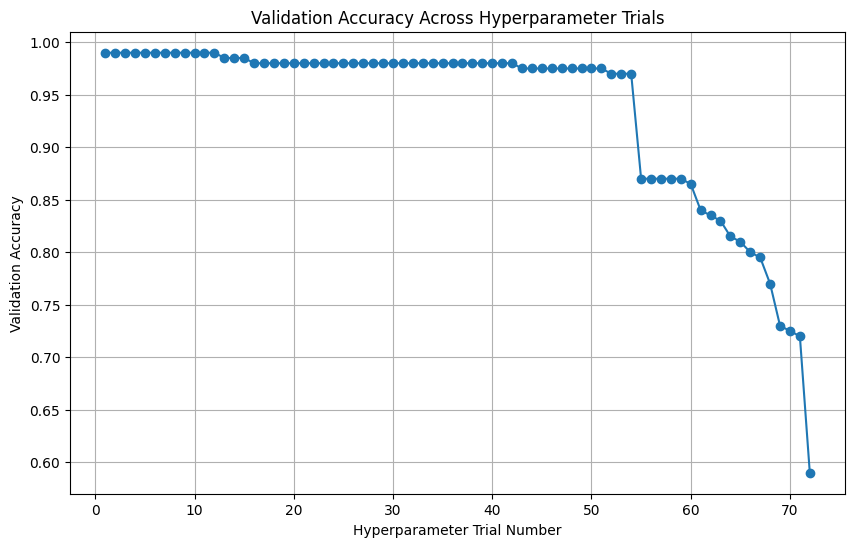

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracies across all trials
val_accuracies = results_df['accuracy'].values
trial_numbers = np.arange(1, len(val_accuracies) + 1)

plt.figure(figsize=(10, 6))
plt.plot(trial_numbers, val_accuracies, marker='o')
plt.xlabel('Hyperparameter Trial Number')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Across Hyperparameter Trials')
plt.grid(True)
plt.show()

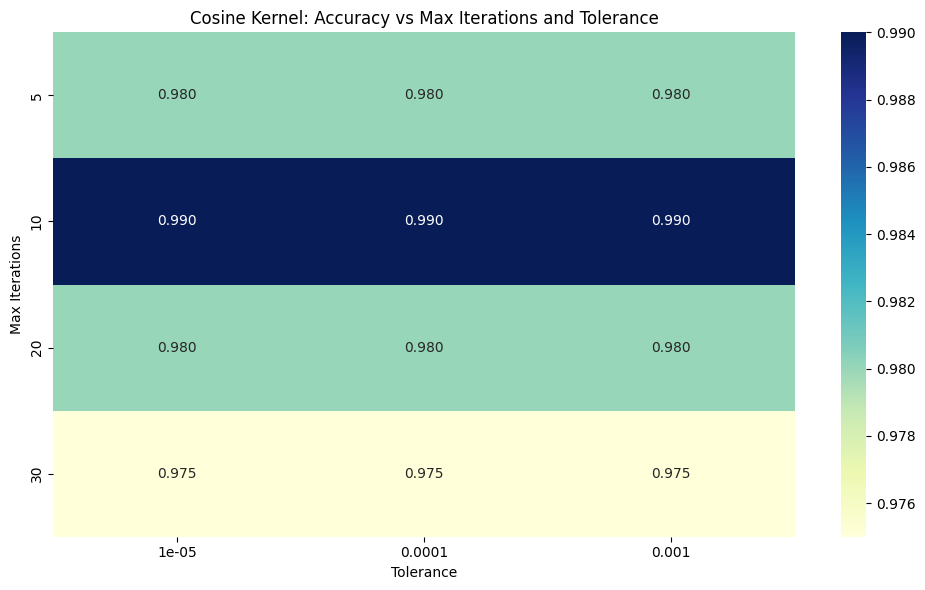

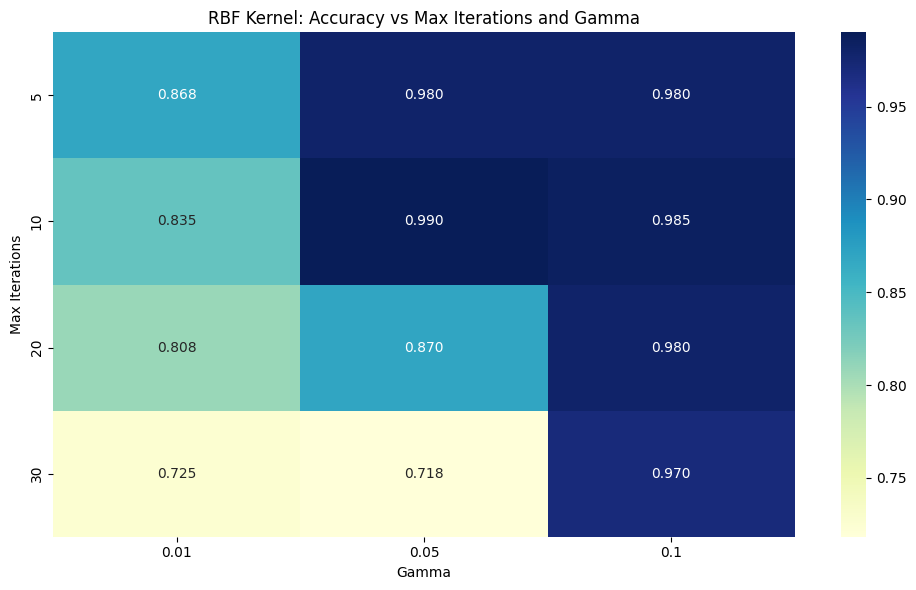

In [ ]:
# Prepare columns
results_df['kernel'] = results_df['params'].apply(lambda d: d['kernel'])
results_df['gamma'] = results_df['params'].apply(lambda d: d.get('gamma', None))
results_df['max_iter'] = results_df['params'].apply(lambda d: d['max_iter'])
results_df['tol'] = results_df['params'].apply(lambda d: d['tol'])

# Plot: Cosine Kernel - Accuracy vs max_iter & tol
cosine_df = results_df[results_df['kernel'] == 'cosine']
pivot_cosine = cosine_df.pivot_table(index='max_iter', columns='tol', values='accuracy')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_cosine, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title('Cosine Kernel: Accuracy vs Max Iterations and Tolerance')
plt.xlabel('Tolerance')
plt.ylabel('Max Iterations')
plt.tight_layout()
plt.show()

# Plot: RBF Kernel - Accuracy vs max_iter & gamma
rbf_df = results_df[results_df['kernel'] == 'rbf']
pivot_rbf = rbf_df.pivot_table(index='max_iter', columns='gamma', values='accuracy')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_rbf, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title('RBF Kernel: Accuracy vs Max Iterations and Gamma')
plt.xlabel('Gamma')
plt.ylabel('Max Iterations')
plt.tight_layout()
plt.show()

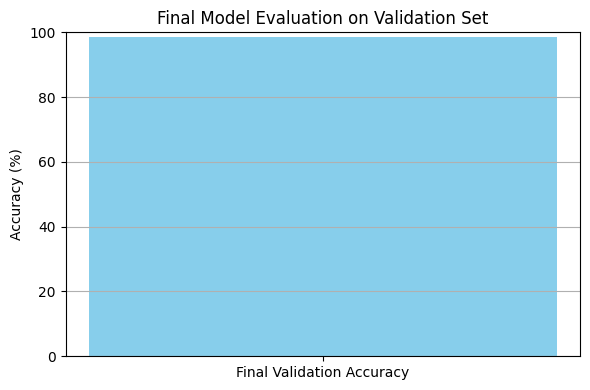

In [ ]:
# Plot final_val_accuracy
final_accuracy_percentage = final_val_accuracy * 100

plt.figure(figsize=(6, 4))
plt.bar(['Final Validation Accuracy'], [final_accuracy_percentage], color='skyblue')
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Final Model Evaluation on Validation Set')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations_with_replacement
from tqdm import tqdm
import time

# Creating a dummy df_test from validation labels
df_test = pd.DataFrame({
    'img_bytes': [None] * len(X_val),
    'label': y_val
})

#Get the number of test examples
num_test = len(df_test)
print(f"Total test images: {num_test}")

#Calculate total number of pairs (n*(n+1)/2) for combinations_with_replacement
total_pairs = num_test * (num_test + 1) // 2
print(f"Total test pairs to generate: {total_pairs:,}")

#Initialize lists to store pairs and their attributes
image_A_indices = []
image_B_indices = []
image_A_bytes = []
image_B_bytes = []
label_As = []
label_Bs = []

#Create progress bar with time estimation
start_time = time.time()

with tqdm(total=total_pairs, desc="Generating test pairs", unit="pair") as pbar:
    for i, j in combinations_with_replacement(range(num_test), 2):
        image_A_indices.append(i)
        image_B_indices.append(j)
        image_A_bytes.append(df_test['img_bytes'].iloc[i])
        image_B_bytes.append(df_test['img_bytes'].iloc[j])
        label_As.append(df_test['label'].iloc[i])
        label_Bs.append(df_test['label'].iloc[j])
        pbar.update(1)

#Create DataFrame from collected data
test_data = pd.DataFrame({
    'image_A_index': image_A_indices,
    'image_B_index': image_B_indices,
    'image_A_bytes': image_A_bytes,
    'image_B_bytes': image_B_bytes,
    'label_A': label_As,
    'label_B': label_Bs
})

#Add same_label column
test_data['same_label'] = (test_data['label_A'] == test_data['label_B']).astype(int)

elapsed_time = time.time() - start_time
print(f"\nCompleted in {elapsed_time:.2f} seconds")
print("Test pairs DataFrame created with columns:")
print(test_data.columns)
print(f"\nFirst few pairs:\n{test_data.head()}")

Total test images: 200
Total test pairs to generate: 20,100


Generating test pairs: 100%|██████████| 20100/20100 [00:00<00:00, 26661.91pair/s]


Completed in 0.80 seconds
Test pairs DataFrame created with columns:
Index(['image_A_index', 'image_B_index', 'image_A_bytes', 'image_B_bytes',
       'label_A', 'label_B', 'same_label'],
      dtype='object')

First few pairs:
   image_A_index  image_B_index image_A_bytes image_B_bytes  label_A  label_B  \
0              0              0          None          None        0        0   
1              0              1          None          None        0        1   
2              0              2          None          None        0        0   
3              0              3          None          None        0        1   
4              0              4          None          None        0        0   

   same_label  
0           1  
1           0  
2           1  
3           0  
4           1  
